# Task 5 — Addestramento di più classificatori con Scikit-Learn

> 📄 Documentazione completa e motivazioni: [`docs/task5.md`](../docs/task5.md)

## 1. Import e configurazione

Il **punto 5 della traccia** chiede di addestrare, tramite scikit-learn, **più classificatori**
su `training.csv`, separando opportunamente training e test set, con l'obiettivo di
**massimizzare le prestazioni sul test** e di selezionare poi il modello migliore (che in sede
d'esame sarà valutato su `real_settings.csv`). Importiamo tutto l'occorrente: utility per lo
split e il tuning (`train_test_split`, `GridSearchCV`, `StratifiedKFold`), gli strumenti di
preprocessing (`ColumnTransformer`, `Pipeline`, `OneHotEncoder`, `StandardScaler`,
`SimpleImputer`), i cinque algoritmi di classificazione e le metriche. Fissiamo `SEED = 10` per
la riproducibilità.

> **Nota.** I notebook del corso usano solo pandas/numpy/matplotlib; tutto il lavoro con
> scikit-learn di questo task è un **contributo originale**, non una replica dello stile del
> docente. Lo stile completamente vettoriale adottato (niente cicli `for`) è anch'esso una
> scelta deliberata, più rigorosa della pratica vista a lezione.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             average_precision_score, roc_auc_score,
                             precision_recall_curve, PrecisionRecallDisplay)

SEED = 10
np.random.seed(SEED)
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
print("Librerie importate. SEED =", SEED)

Librerie importate. SEED = 10


## 2. Caricamento di `training.csv`

Carichiamo il dataset pulito prodotto nel Task 1 e ne verifichiamo la composizione. Il punto
saliente è la **distribuzione del target**: la classe positiva (`yes`, sottoscrizione) è una
minoranza (~11–14%). Questo **sbilanciamento** è il filo conduttore di tutte le scelte
successive — metrica di ottimizzazione, ribilanciamento dei pesi, soglia decisionale — ed è la
ragione per cui l'accuratezza non può essere il criterio guida.

In [2]:
df = pd.read_csv("../data/processed/training.csv", sep=",")
print("Dimensioni:", df.shape)
print("\nDistribuzione del target (y):")
print(df["y"].value_counts())
print("\nProporzione classe 'yes':",
      round(df["y"].mean() * 100, 2), "%")
df.head()

Dimensioni: (41176, 21)

Distribuzione del target (y):
y
0    36537
1     4639
Name: count, dtype: int64

Proporzione classe 'yes': 11.27 %


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


## 3. Rimozione della *data leakage*: la feature `duration`

### Perché `duration` è un problema

La feature `duration` registra la **durata in secondi dell'ultima telefonata** al cliente. È
fortemente correlata con l'esito (chi sottoscrive tende a parlare più a lungo), ma contiene
**data leakage**: la durata è nota **solo dopo** aver concluso la chiamata, cioè dopo che l'esito
si è di fatto già determinato. Un modello che la usa "bara", sfruttando informazione che nella
realtà non sarebbe disponibile **al momento della decisione** (chiamare o no un cliente). Le sue
prestazioni risulterebbero gonfiate e non replicabili in produzione.

### Il legame diretto con `real_settings.csv`

C'è anche una ragione pratica e stringente: in sede d'esame il modello sarà testato su
`real_settings.csv`, un file che simula **condizioni reali di utilizzo** — cioè il momento *prima*
di contattare il cliente, quando `duration` semplicemente **non esiste ancora**. Addestrare il
modello con `duration` lo renderebbe inutilizzabile su quel file. Per coerenza con lo scenario di
valutazione finale, la **rimuoviamo subito** e definitivamente.

In [3]:
# Rimuoviamo 'duration' per evitare data leakage (coerente con real_settings.csv)
df_model = df.drop(columns=["duration"])

# Separiamo feature (X) e target (y)
X = df_model.drop(columns=["y"])
y = df_model["y"]

print("Feature rimaste:", X.shape[1])
print("Colonne:", list(X.columns))

Feature rimaste: 19
Colonne: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


## 4. Distinzione tra attributi numerici e categorici

Per applicare il preprocessing corretto a ciascun gruppo di colonne, separiamo automaticamente
gli attributi **numerici** da quelli **categorici** in base al tipo di dato (Lezione 3), senza
elencarli a mano e senza cicli. Numerici e categorici richiedono trasformazioni diverse
(standardizzazione i primi, codifica one-hot i secondi): questa distinzione è il presupposto del
`ColumnTransformer` costruito più avanti.

In [4]:
# Selezione automatica per tipo, senza cicli (Lezione 3: numerici vs nominali)
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include="object").columns

print(f"Attributi NUMERICI ({len(num_cols)}):")
print(" ", list(num_cols))
print(f"\nAttributi CATEGORICI ({len(cat_cols)}):")
print(" ", list(cat_cols))

Attributi NUMERICI (9):
  ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Attributi CATEGORICI (10):
  ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


/tmp/ipykernel_706/611006401.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


## 5. Separazione in training set e test set (holdout 70/30 stratificato)

Separiamo i dati in **70% training** e **30% test** con holdout **stratificato** (Lezione 8):
l'opzione `stratify=y` garantisce che la proporzione della classe rara sia identica nei due
sottoinsiemi (come confermano le proporzioni stampate). Su dati sbilanciati la stratificazione è
essenziale: senza, il test set potrebbe contenere troppo pochi esempi positivi per una stima
affidabile. Il test set viene **messo da parte** e usato solo alla fine, per la valutazione
finale; tutto il tuning avverrà in cross-validation **solo sul training**, per non contaminare
la stima.

In [5]:
# Holdout stratificato 70/30 (Lezione 8)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,          # conserva la proporzione delle classi
    random_state=SEED    # riproducibilità
)

print(f"Training set: {X_train.shape[0]} campioni")
print(f"Test set:     {X_test.shape[0]} campioni")
print(f"\nProporzione 'yes' nel training: {y_train.mean():.4f}")
print(f"Proporzione 'yes' nel test:     {y_test.mean():.4f}")
print("\n-> le proporzioni coincidono: la stratificazione ha funzionato.")

Training set: 28823 campioni
Test set:     12353 campioni

Proporzione 'yes' nel training: 0.1127
Proporzione 'yes' nel test:     0.1127

-> le proporzioni coincidono: la stratificazione ha funzionato.


## 6. Costruzione del preprocessing con `ColumnTransformer`

### Perché la pipeline e non trasformare i dati "a mano"?

Trasformare i dati separatamente (scalare, codificare, imputare) prima dello split o fuori da una
struttura controllata è la causa più comune di **data leakage** silenzioso: se, ad esempio, si
calcola la media per la standardizzazione sull'intero dataset, l'informazione del test "filtra"
nel training. La **`Pipeline`** di scikit-learn risolve il problema alla radice: incapsula
preprocessing e classificatore in un unico oggetto che, durante la cross-validation, viene
**adattato solo sulla porzione di training di ogni fold** e applicato al fold di validazione.
Questo garantisce una stima onesta e rende il flusso riproducibile e applicabile tale e quale a
nuovi dati.

### I due rami

Il **`ColumnTransformer`** instrada ciascun gruppo di colonne nel ramo appropriato (Lezione 11):

- **ramo numerico** → imputazione dei mancanti con la **mediana** (robusta agli outlier) seguita
  da **standardizzazione** (`StandardScaler`), utile soprattutto ai modelli sensibili alla scala
  come KNN e regressione logistica;
- **ramo categorico** → imputazione con la **moda** seguita da **one-hot encoding** (Lezione 11),
  con `handle_unknown="ignore"` per gestire eventuali categorie mai viste nel training (cruciale
  per la robustezza su `real_settings.csv`) e `sparse_output=False` perché `GaussianNB` richiede
  una matrice densa.

In [6]:
# Ramo numerico: imputazione mediana + standardizzazione (Lezione 11)
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Ramo categorico: imputazione moda + one-hot encoding (Lezione 11)
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# ColumnTransformer: applica ogni ramo al gruppo di colonne corretto
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

print("Preprocessor costruito:")
print(preprocessor)

Preprocessor costruito:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='str')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['job', 'marital', 'education', 'default', 'housing

## 7. Gestione dello sbilanciamento delle classi

### Conseguenza 1 — l'accuracy è fuorviante

Con ~89% di esempi negativi, un classificatore che predice **sempre `no`** raggiunge un'accuratezza
dell'~89% pur essendo **inutile** (non individua alcun cliente interessato). L'accuratezza, da
sola, premia questo comportamento degenere: è quindi una metrica **fuorviante** in questo
contesto. Le metriche operative diventano **precision, recall e F1 sulla classe minoritaria**,
che misurano la reale capacità di individuare i clienti positivi.

### Conseguenza 2 — serve ribilanciare il costo degli errori

Lasciati liberi, i modelli tendono a ignorare la classe rara perché sbagliarla incide poco
sull'errore complessivo. Per contrastare questo effetto usiamo **`class_weight="balanced"`** sui
modelli che lo supportano (albero, regressione logistica, random forest): l'opzione pesa gli
errori in modo **inversamente proporzionale alla frequenza** delle classi, rendendo molto più
"costoso" sbagliare un esempio positivo. È una soluzione interna al modello, preferita a tecniche
di ricampionamento come SMOTE perché non altera i dati, non introduce esempi sintetici e si
integra naturalmente nella pipeline e nella cross-validation. Una leva complementare, esplorata
più avanti, è lo spostamento della **soglia decisionale**.

## 8. Definizione dei cinque classificatori e delle griglie di iperparametri

Mettiamo a confronto **cinque classificatori** visti (o richiamati) a lezione: **Naïve Bayes**,
**KNN**, **Albero di decisione**, **Regressione logistica** e **Random Forest**. Per ciascuno
definiamo una **griglia di iperparametri** da esplorare in fase di tuning. I modelli che lo
supportano vengono inizializzati con `class_weight="balanced"` (vedi sezione precedente). La
struttura scelta — un dizionario `{nome: (stimatore, griglia)}` — permette di addestrare e
valutare tutti i modelli con un'unica funzione, applicata in modo vettoriale, senza duplicare
codice e senza cicli espliciti.

In [7]:
# Dizionario {nome: (stimatore, griglia di iperparametri)}
# I modelli che lo supportano usano class_weight='balanced' (Sezione 7).
models = {
    "Naive Bayes": (
        GaussianNB(),
        {"clf__var_smoothing": [1e-9, 1e-7, 1e-5]},
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"clf__n_neighbors": [15, 31, 51],
         "clf__weights": ["uniform", "distance"]},
    ),
    "Albero": (
        DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
        {"clf__max_depth": [5, 10, None],
         "clf__min_samples_leaf": [1, 20]},
    ),
    "Logistica": (
        LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED),
        {"clf__C": [0.1, 1.0, 10.0]},
    ),
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
        {"clf__n_estimators": [200],
         "clf__max_depth": [10, None],
         "clf__min_samples_leaf": [1, 5]},
    ),
}

print("Modelli definiti:", list(models.keys()))

Modelli definiti: ['Naive Bayes', 'KNN', 'Albero', 'Logistica', 'Random Forest']


## 9. Scelta della metrica di ottimizzazione

Coerentemente con l'analisi sullo sbilanciamento, scegliamo come metrica guida del tuning la
**F1-score sulla classe positiva**. La F1 è la media armonica di precision e recall: premia i
modelli che individuano molti clienti interessati (recall alta) **senza** generare troppi falsi
allarmi (precision accettabile). È la scelta giusta quando entrambi i tipi di errore contano e la
classe è rara — diversamente dall'accuratezza, che sarebbe massimizzata dal degenere "sempre no".
Il `GridSearchCV` ottimizzerà quindi gli iperparametri massimizzando la F1 in cross-validation.

## 10. Addestramento, tuning e valutazione dei cinque modelli

Per ogni classificatore costruiamo la **pipeline completa** (preprocessing + modello),
ottimizziamo gli iperparametri con **`GridSearchCV`** in **cross-validation stratificata a 5
fold** (Lezioni 8–9) massimizzando la F1, e valutiamo il modello migliore **sul test set** messo
da parte. La cross-validation stratificata mantiene la proporzione di classi in ogni fold, dando
una stima stabile su dati sbilanciati. Raccogliamo per ciascun modello la F1 in CV e le metriche
sul test, così da poterli confrontare in modo uniforme. L'intero processo è applicato a tutti i
modelli tramite `apply`, senza cicli espliciti.

In [8]:
# Cross-validation stratificata per il tuning (Lezione 8-9)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def valuta_modello(nome):
    # Costruisce la pipeline, ottimizza gli iperparametri via GridSearchCV
    # e valuta il modello migliore sul test set. Restituisce una Series di risultati.
    stimatore, griglia = models[nome]

    # Pipeline completa: preprocessing + classificatore
    pipe = Pipeline([("prep", preprocessor), ("clf", stimatore)])

    # Tuning con cross-validation, ottimizzando la F1 (Sezione 9)
    search = GridSearchCV(pipe, griglia, scoring="f1", cv=cv, n_jobs=-1)
    search.fit(X_train, y_train)

    best = search.best_estimator_
    pred = best.predict(X_test)
    # Probabilità per le metriche di ranking (tutti questi modelli hanno predict_proba)
    proba = best.predict_proba(X_test)[:, 1]

    return pd.Series({
        "modello": nome,
        "best_params": str(search.best_params_),
        "cv_f1": search.best_score_,
        "test_f1": f1_score(y_test, pred),
        "test_pr_auc": average_precision_score(y_test, proba),
        "test_roc_auc": roc_auc_score(y_test, proba),
        "test_accuracy": (pred == y_test).mean(),
        "_estimator": best,
        "_pred": pred,
        "_proba": proba,
    })

# Applichiamo la funzione a tutti i modelli senza cicli espliciti.
# apply che restituisce una Series produce direttamente un DataFrame.
risultati = (pd.Index(list(models.keys()))
             .to_series()
             .apply(valuta_modello)
             .reset_index(drop=True))

print("Addestramento e tuning completati per tutti i modelli.")

Addestramento e tuning completati per tutti i modelli.


### Tabella comparativa dei risultati

Raccogliamo i risultati dei cinque modelli in un'unica tabella, ordinata per **F1 sul test set**
(la nostra metrica obiettivo). La tabella riporta anche F1 in cross-validation, PR-AUC, ROC-AUC e
accuratezza, per una lettura a tutto tondo. La **coerenza tra F1 in CV e F1 sul test** è un buon
indicatore di assenza di overfitting nel tuning: se i due valori sono vicini, la stima in
cross-validation ha "tenuto" anche sui dati mai visti.

In [9]:
# Colonne metriche (escludiamo quelle che iniziano con '_', di servizio)
colonne_metriche = ["modello", "cv_f1", "test_f1",
                    "test_pr_auc", "test_roc_auc", "test_accuracy"]

tabella = (risultati[colonne_metriche]
           .sort_values("test_f1", ascending=False)
           .reset_index(drop=True))

# Arrotondamento per leggibilità (round vettorizzato, no loop)
tabella_display = tabella.copy()
tabella_display[colonne_metriche[1:]] = tabella_display[colonne_metriche[1:]].round(4)
tabella_display

,modello,cv_f1,test_f1,test_pr_auc,test_roc_auc,test_accuracy
0,Random Forest,0.5016,0.5023,0.4650,0.7996,0.8673
1,Albero,0.4531,0.4672,0.4120,0.7830,0.8447
2,Logistica,0.4504,0.4564,0.4440,0.7962,0.8289
3,Naive Bayes,0.4208,0.4140,0.3445,0.7721,0.8460
4,KNN,0.3626,0.3666,0.3521,0.7539,0.8926


### Confronto visuale: F1 vs Accuracy

Il grafico contrappone, per ogni modello, la **F1 sulla minoranza** e l'**accuratezza**,
riportando come riferimento la linea dell'accuratezza del baseline "sempre no". È la
rappresentazione più eloquente del problema: diversi modelli hanno **accuratezza inferiore al
baseline** ma **F1 molto più alta**, perché — grazie al ribilanciamento — individuano realmente i
clienti positivi invece di limitarsi a predire la classe maggioritaria. Conferma visivamente
perché ottimizzare l'accuratezza sarebbe stato un errore.

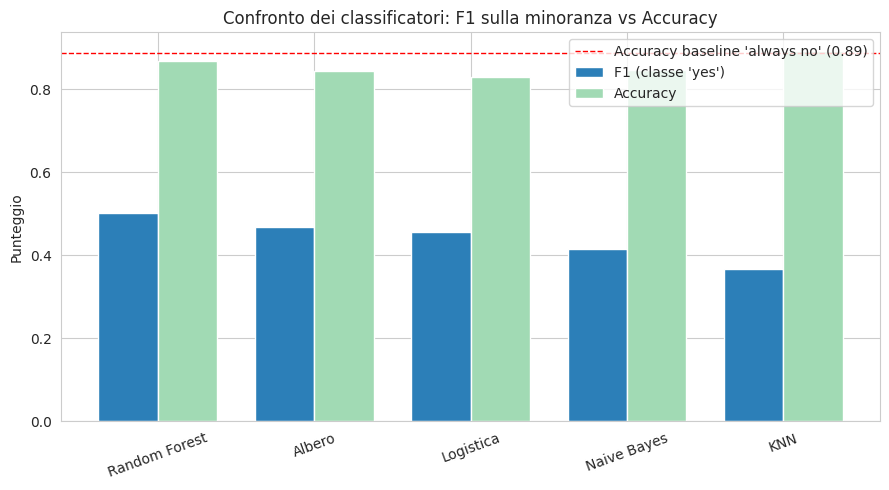

In [10]:
baseline_acc = 1 - y_test.mean()   # accuracy del modello "predici sempre no"

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(tabella))
larghezza = 0.38

ax.bar(x - larghezza/2, tabella["test_f1"], larghezza,
       label="F1 (classe 'yes')", color="#2c7fb8")
ax.bar(x + larghezza/2, tabella["test_accuracy"], larghezza,
       label="Accuracy", color="#a1dab4")
ax.axhline(baseline_acc, color="red", linestyle="--", linewidth=1,
           label=f"Accuracy baseline 'always no' ({baseline_acc:.2f})")

ax.set_xticks(x)
ax.set_xticklabels(tabella["modello"], rotation=20)
ax.set_ylabel("Punteggio")
ax.set_title("Confronto dei classificatori: F1 sulla minoranza vs Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Selezione del classificatore finale e analisi critica

Selezioniamo il modello con la **F1 più alta sul test set**, individuato automaticamente con
`idxmax`. Ne stampiamo gli iperparametri ottimali e le metriche complete, e ne analizziamo il
comportamento con matrice di confusione e classification report. La scelta del "migliore" è
sempre **relativa alla metrica obiettivo**: qui la F1 sulla classe rara, in linea con
l'obiettivo applicativo di non perdere clienti potenziali.

In [11]:
# Indice del modello migliore per F1 sul test (idxmax, no loop)
idx_best = risultati["test_f1"].idxmax()
best_row = risultati.loc[idx_best]

print("=" * 55)
print(f"  MODELLO SELEZIONATO: {best_row['modello']}")
print("=" * 55)
print(f"  Iperparametri ottimali: {best_row['best_params']}")
print(f"  F1 (cross-validation):  {best_row['cv_f1']:.4f}")
print(f"  F1 (test set):          {best_row['test_f1']:.4f}")
print(f"  PR-AUC (test set):      {best_row['test_pr_auc']:.4f}")
print(f"  ROC-AUC (test set):     {best_row['test_roc_auc']:.4f}")

  MODELLO SELEZIONATO: Random Forest
  Iperparametri ottimali: {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}
  F1 (cross-validation):  0.5016
  F1 (test set):          0.5023
  PR-AUC (test set):      0.4650
  ROC-AUC (test set):     0.7996


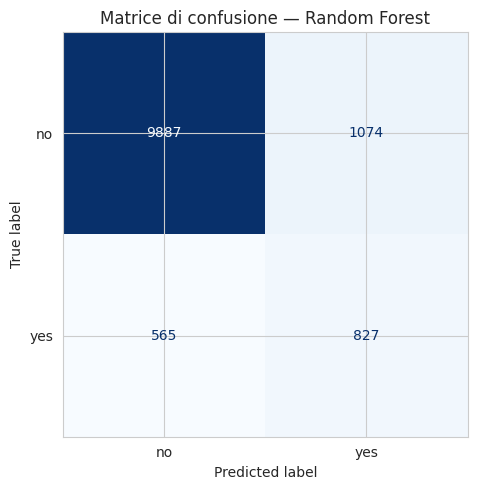


Classification report dettagliato:

              precision    recall  f1-score   support

          no       0.95      0.90      0.92     10961
         yes       0.44      0.59      0.50      1392

    accuracy                           0.87     12353
   macro avg       0.69      0.75      0.71     12353
weighted avg       0.89      0.87      0.88     12353



In [12]:
# Matrice di confusione del modello finale (Lezione 8)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_row["_pred"],
    display_labels=["no", "yes"],
    cmap="Blues", ax=ax, colorbar=False
)
ax.set_title(f"Matrice di confusione — {best_row['modello']}")
plt.tight_layout()
plt.show()

print("\nClassification report dettagliato:\n")
print(classification_report(y_test, best_row["_pred"],
                            target_names=["no", "yes"]))

### Curva Precision-Recall e ruolo della soglia decisionale

La **curva Precision-Recall** è lo strumento più informativo per valutare un classificatore su
classi sbilanciate (più della curva ROC, che può apparire ottimistica). Mostra il **trade-off**
tra precision e recall al variare della **soglia decisionale**: di default scikit-learn classifica
come positivo ciò che supera probabilità 0.5, ma **abbassando la soglia** si aumenta la recall (si
individuano più positivi) a scapito della precision, e viceversa. La linea di riferimento è la
precision di un classificatore casuale, pari alla **prevalenza della classe**. La scelta della
soglia "giusta" non è statistica ma **di business**: dipende da quanto costa un falso negativo
(cliente perso) rispetto a un falso positivo (chiamata sprecata).

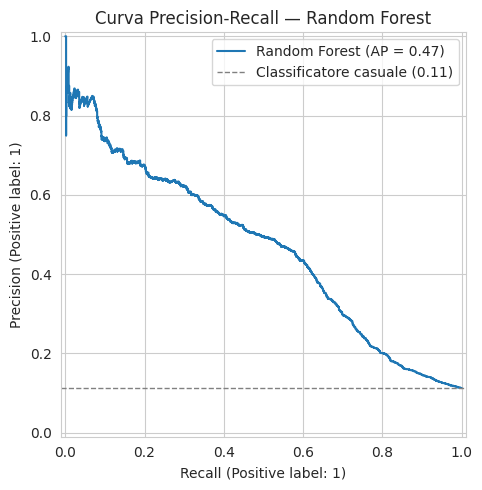

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, best_row["_proba"], name=best_row["modello"], ax=ax
)
# Linea di riferimento: precision di un classificatore casuale = prevalenza della classe
ax.axhline(y_test.mean(), color="grey", linestyle="--", linewidth=1,
           label=f"Classificatore casuale ({y_test.mean():.2f})")
ax.set_title(f"Curva Precision-Recall — {best_row['modello']}")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 12. Discussione critica dei risultati

Tirando le somme dell'intero confronto:

- **Tutti i modelli affrontano lo stesso ostacolo**: senza `duration`, il segnale predittivo
  residuo è modesto e nessun modello raggiunge una F1 elevata sulla classe rara. È un risultato
  **onesto**, non un limite dell'implementazione: rispecchia la reale difficoltà di prevedere la
  sottoscrizione a partire dalle sole informazioni disponibili *prima* del contatto.
- **Il ribilanciamento funziona**: i modelli con `class_weight="balanced"` recuperano molta recall
  rispetto a quanto farebbero in configurazione standard, al prezzo di una precision più bassa e
  di un'accuratezza sotto il baseline — esattamente il trade-off che abbiamo scelto di accettare.
- **La metrica decide il vincitore**: avendo ottimizzato la F1, il modello selezionato non è
  quello con l'accuratezza più alta, ma quello che meglio bilancia individuazione dei positivi e
  contenimento dei falsi allarmi.
- **Limiti e possibili estensioni**: si potrebbe esplorare l'ottimizzazione esplicita della soglia
  decisionale, l'ingegnerizzazione di nuove feature, o tecniche di ricampionamento; ma nel
  rispetto del vincolo di usare principalmente metodi visti a lezione, la strada del
  ribilanciamento via pesi è la più appropriata e difendibile.

## 13. Predisposizione per `real_settings.csv` (esame)

Prepariamo infine il codice che verrà eseguito in sede d'esame, quando sarà fornito il file
`real_settings.csv`. La logica è semplice perché tutto il lavoro è già incapsulato nella
**pipeline addestrata**: basta caricare il nuovo file, applicare le **stesse trasformazioni**
(in particolare la rimozione di `duration`, per coerenza anti-leakage), e chiamare `predict`. La
pipeline applica automaticamente lo stesso preprocessing del training — imputazione, scaling,
one-hot con gestione delle categorie sconosciute — senza alcun intervento manuale e senza rischio
di disallineamento tra training e dati nuovi. Se il file conterrà la colonna `y`, valuteremo le
prestazioni con le stesse metriche usate qui.

In [14]:
# ============================================================
#  TEMPLATE PER L'ESAME — eseguire quando si riceve real_settings.csv
# ============================================================
# modello_finale = best_row["_estimator"]   # pipeline completa già addestrata
#
# real = pd.read_csv("real_settings.csv")    # adattare sep= se necessario
#
# # Allineamento alle stesse feature del training:
# real = real.drop(columns=["duration"], errors="ignore")  # coerenza anti-leakage
# X_real = real.drop(columns=["y"], errors="ignore")
#
# # Predizione (la pipeline applica preprocessing identico al training)
# pred_real = modello_finale.predict(X_real)
#
# # Se il file contiene la colonna 'y', valutiamo le prestazioni:
# if "y" in real.columns:
#     y_real = real["y"]
#     print(classification_report(y_real, pred_real, target_names=["no", "yes"]))
#     ConfusionMatrixDisplay.from_predictions(y_real, pred_real,
#                                             display_labels=["no", "yes"], cmap="Blues")
#     plt.show()
# else:
#     print("Predizioni generate:", pd.Series(pred_real).value_counts().to_dict())
print("Template pronto. Decommentare ed eseguire in sede d'esame.")

Template pronto. Decommentare ed eseguire in sede d'esame.


## 14. Conclusioni

In questo task abbiamo:

1. **rimosso la data leakage** escludendo `duration`, in coerenza con il test in
   condizioni reali (`real_settings.csv`);
2. costruito **pipeline complete** con `ColumnTransformer` (imputazione + scaling +
   one-hot), evitando ogni contaminazione tra training e test;
3. addestrato e **ottimizzato cinque classificatori** del corso con `GridSearchCV` e
   cross-validation stratificata;
4. **gestito lo sbilanciamento** con `class_weight="balanced"`, motivando la scelta
   rispetto a SMOTE;
5. valutato i modelli con la **metrica corretta** (F1 sulla minoranza, con PR-AUC di
   supporto), evitando la trappola dell'accuracy;
6. **selezionato il classificatore finale** e analizzato criticamente i risultati,
   collegandoli ai concetti delle Lezioni 3, 5–9 e 11.

Il modello scelto è incapsulato in una pipeline riutilizzabile, **pronta** per essere
applicata al file d'esame senza ulteriore preprocessing manuale.

### Concetti del corso utilizzati (riepilogo)

| Concetto | Lezione | Dove |
|---|---|---|
| Attributi numerici vs nominali | 3 | Sez. 4 |
| Naïve Bayes, KNN, alberi, modelli lineari | 5–7 | Sez. 8 |
| Holdout, stratificazione, metriche, confusion matrix | 8 | Sez. 5, 9, 11 |
| Cross-validation, tuning (GridSearchCV) | 9 | Sez. 10 |
| One-hot encoding, scaling, imputazione | 11 | Sez. 6 |
| Data leakage | trasversale | Sez. 3 |
| Sbilanciamento e `class_weight` | trasversale | Sez. 7 |
